In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

2026-06-06 16:24:02.152726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780763042.333520      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780763042.391220      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780763042.776528      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780763042.776574      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780763042.776577      58 computation_placer.cc:177] computation placer alr

# Dataset Loading

The Intel Image Classification dataset is loaded and divided into training, validation, and test datasets.

In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(150,150),
    batch_size=32
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1780763174.567294      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780763174.573466      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(150,150),
    batch_size=32
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [5]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test",
    image_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


# Data Augmentation

Data augmentation techniques such as random flipping, rotation, and zooming are applied to improve model generalization and reduce overfitting.

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data Augmentation Created Successfully")

Data Augmentation Created Successfully


In [7]:
class_names = train_dataset.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# CNN Model Development

A custom Convolutional Neural Network (CNN) is designed for scene classification.

In [8]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

cnn_model = Sequential([

    Input(shape=(150,150,3)),

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model Compiled Successfully")

CNN Model Compiled Successfully


In [10]:
history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10


I0000 00:00:1780763424.260648     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.5232 - loss: 1.2056 - val_accuracy: 0.6415 - val_loss: 0.9782
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6310 - loss: 0.9839 - val_accuracy: 0.7110 - val_loss: 0.7800
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6706 - loss: 0.8937 - val_accuracy: 0.7527 - val_loss: 0.6945
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6942 - loss: 0.8211 - val_accuracy: 0.7284 - val_loss: 0.7670
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7235 - loss: 0.7702 - val_accuracy: 0.7520 - val_loss: 0.6774
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7372 - loss: 0.7195 - val_accuracy: 0.7470 - val_loss: 0.6482
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7523 - loss: 0.6943 - val_accuracy: 0.7890 - val_loss: 0.5716
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7602 - loss: 0.6742 - val_accurac

# CNN Model Evaluation

The trained CNN model is evaluated on the test dataset.

In [11]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_dataset)

print("CNN Test Accuracy:", cnn_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8120 - loss: 0.5455
CNN Test Accuracy: 0.8119999766349792


# CNN Accuracy and Loss Curves

Training and validation performance are visualized using accuracy and loss curves.

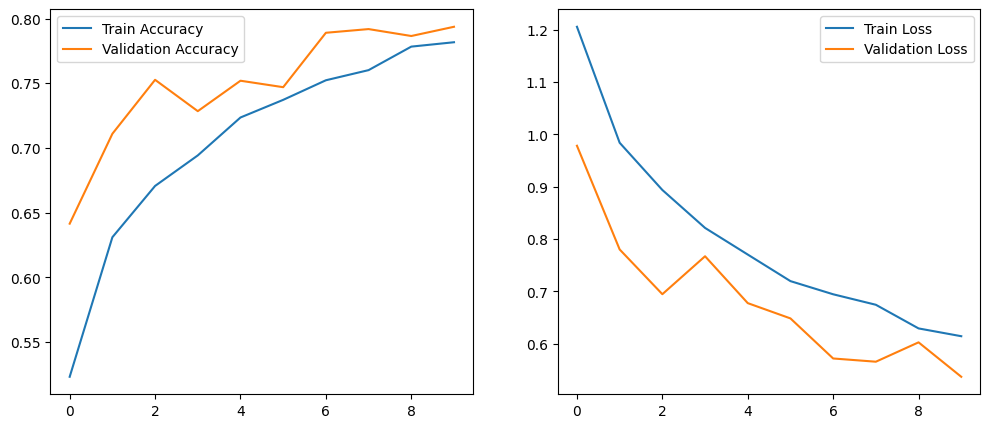

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()

plt.savefig("cnn_accuracy_loss_curve.png")
plt.show()

In [15]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

y_pred_probs = cnn_model.predict(test_dataset)

y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions generated successfully")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Predictions generated successfully


# CNN Confusion Matrix

The confusion matrix provides a detailed view of classification performance for each class.

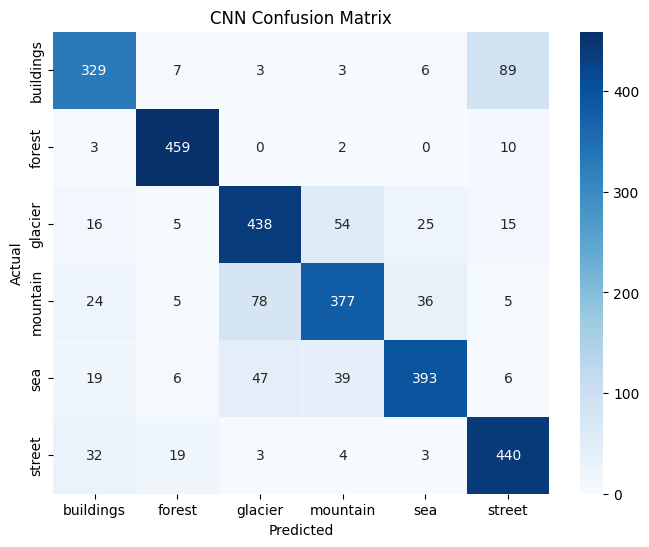

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("cnn_confusion_matrix.png")
plt.show()

# CNN Classification Report

Precision, recall, F1-score, and overall accuracy are calculated for the CNN model.

In [33]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

with open("classification_report.txt", "w") as f:
    f.write(report)

print(report)

              precision    recall  f1-score   support

   buildings       0.78      0.75      0.77       437
      forest       0.92      0.97      0.94       474
     glacier       0.77      0.79      0.78       553
    mountain       0.79      0.72      0.75       525
         sea       0.85      0.77      0.81       510
      street       0.78      0.88      0.83       501

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



# Transfer Learning Model - MobileNetV2

In [22]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

mobilenet_model.summary()

/tmp/ipykernel_58/1910490353.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
mobilenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 Compiled Successfully")

MobileNetV2 Compiled Successfully


# MobileNetV2 Training and Evaluation

The MobileNetV2 model is trained and evaluated on the same dataset for performance comparison.

In [24]:
mobilenet_history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.7781 - loss: 0.6147 - val_accuracy: 0.8674 - val_loss: 0.3570
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.8327 - loss: 0.4561 - val_accuracy: 0.8849 - val_loss: 0.3078
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.8434 - loss: 0.4374 - val_accuracy: 0.8724 - val_loss: 0.3225
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.8488 - loss: 0.4110 - val_accuracy: 0.8731 - val_loss: 0.3293
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.8547 - loss: 0.4032 - val_accuracy: 0.8803 - val_loss: 0.3119


In [25]:
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(test_dataset)

print("MobileNetV2 Test Accuracy:", mobilenet_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8830 - loss: 0.3000
MobileNetV2 Test Accuracy: 0.8830000162124634


# Model Comparison

The performance of the CNN and MobileNetV2 models is compared using test accuracy.

In [26]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['CNN + Data Augmentation', 'MobileNetV2'],
    'Test Accuracy': [0.812, 0.883]
})

comparison

,Model,Test Accuracy
0,CNN + Data Augmentation,0.812
1,MobileNetV2,0.883


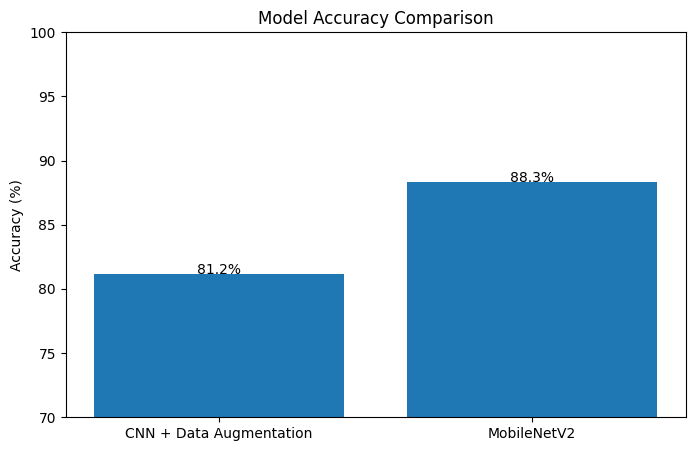

In [31]:
import matplotlib.pyplot as plt

models = ['CNN + Data Augmentation', 'MobileNetV2']
accuracies = [81.2, 88.3]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(70, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center'
    )

plt.savefig('model_comparison.png')
plt.show()

# Error Analysis

Misclassified samples are analyzed to identify challenging classes and common classification errors.

In [35]:
error_summary = (
    misclassified
    .groupby(['Actual', 'Predicted'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

error_summary.head(10)

,Actual,Predicted,Count
4,buildings,street,89
15,mountain,glacier,78
10,glacier,mountain,54
20,sea,glacier,47
21,sea,mountain,39
16,mountain,sea,36
23,street,buildings,32
11,glacier,sea,25
13,mountain,buildings,24
24,street,forest,19


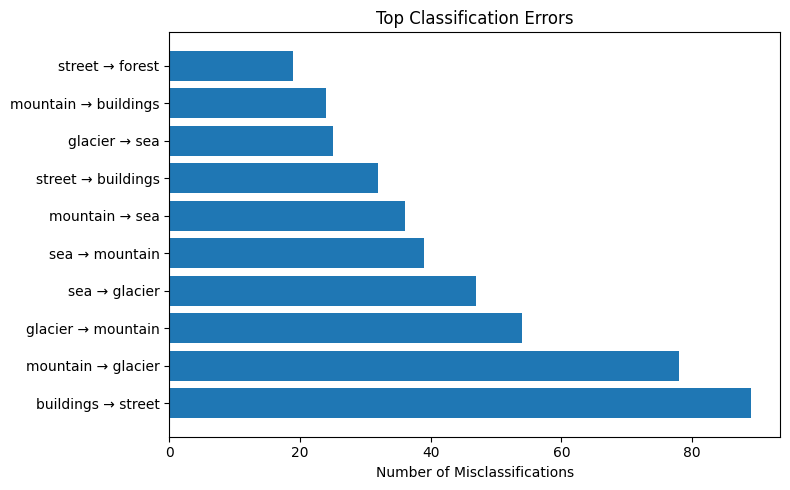

In [36]:
import matplotlib.pyplot as plt

top_errors = error_summary.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_errors['Actual'] + " → " + top_errors['Predicted'],
    top_errors['Count']
)

plt.xlabel("Number of Misclassifications")
plt.title("Top Classification Errors")

plt.tight_layout()
plt.savefig("error_analysis.png")
plt.show()

# Conclusion

The custom CNN achieved 81.2% test accuracy, while MobileNetV2 achieved 88.3% test accuracy. Transfer learning significantly improved classification performance, making MobileNetV2 the best-performing model for this project.